# Simple Methods: Naive and Mean Methods


## Prerequisites:

To start this topic, you must have a proper understanding of the following concepts:

- Time Series data  


## Learning Objective:

- Understand the concept of the Naive method and its mathematical notation.

- Understand the idea of the Mean method and its mathematical notation.


The target of time series analysis is to model the underlying data generation process and use it to make future predictions. We can fit different models for this purpose. In this chapter, we will cover two simple methods: naive method and mean method. We'll look into other sophisticated models like AutoRegressive (AR), Moving Average (MA), AutoRegressive Moving Average (ARMA), Seasonal AutoRegressive Integrated Moving Average (SARIMA), etc. in the future chapters. Similarly, different deep learning-based models, hidden Markov models, etc. are also popular for time series analysis. However, we won't be covering them here.

Let's start by generating a synthetic time-series with 101 data points. We will then discuss how we can make future forecasts using naive and mean methods. 
We've also coded a helper function to plot the time series.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# length of time-series 
T = 101

# Synthetic time series. Draw T samples randomly 
np.random.seed(9999)
X = np.random.randn(T) + 5

In [ ]:
def plot_series(X, X_preds=None, plot_dot=False, plot_mean=False, figsize=(16, 5)):
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
        x_preds (np.array): Forecasted time-series data
        plot_dot (bool): Plots dot for around the last observed data if true
        plot_mean (bool): Plots the mean of the observed data if true

    """
    
    fig = plt.figure(figsize=figsize)
    
    plt.plot(np.arange(len(X)), X, linewidth=3)
    
    if X_preds is not None:
        plt.plot(np.arange(len(X_preds)) + len(X), X_preds, c='#FF0000', linewidth=3)
        plt.legend(['Observed data', 'Forecasted data'], fontsize=15)

    if plot_dot:
        plt.scatter(len(X) - 1, X[-1], marker='o', c='r', linewidth=20)
    
    if plot_mean:
        plt.plot(np.arange(len(X)), np.zeros(len(X)) + np.mean(X), '--', color='#EEAA00',linewidth=3)
        plt.legend(['Observed data', 'Forecasted data', 'Mean Line'], fontsize=14)  

    plt.title('Time Series Plot', fontsize=18)
    plt.xlabel('Time', fontsize=16)
    plt.ylabel('Value of X', fontsize=16)
    plt.grid()
    
    plt.show()

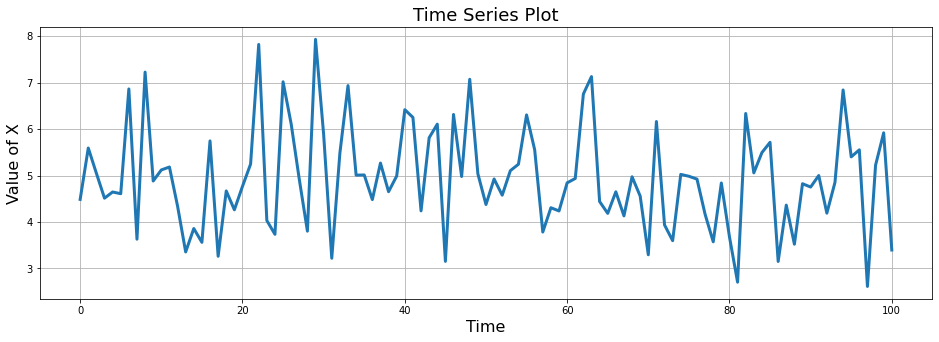

In [ ]:
plot_series(X)

### Naive Method

The naive method is pretty straightforward. Every future forecast is the last observed value. This method does not have any parameter to learn or optimize, so the method is not necessarily a machine learning model. Suppose we've observed data up to time $T$. Let the observed data be a sequence $\{x_t\} _{t = 0} ^T $. Using the naive method, the future forecasts (i.e. at timestamps $T + k, \quad k = 1, 2, ...)$ will be the last observed value $x_T$.



#### Mathematical Expression

Given a time-series $X = \{x_t\} _{t = 0} ^T$, the naive method predicts future predictions as:

> $X_{T + k} = x_T \quad \quad k = 1, 2, ...$



#### Implementation

Let's implement the naive method. We'll define a class named `NaiveMethod` with two methods: `__init__` and `forecast`. 


In [ ]:
# implementation of naive method

class NaiveMethod:
    def __init__(self, X):
        self.last_val = X[-1] # store the last value of observed data

    def forecast(self, n=1):
        """ Forecast function

            Args:
                n (int): Number of forecasts to make
            
            Returns:
                np.array: of length n with all values equal to last_val
        """

        return np.zeros(n) + self.last_val 

In [ ]:
naive = NaiveMethod(X)

# generate 10 forecasts using the naive method
X_preds = naive.forecast(n=10)

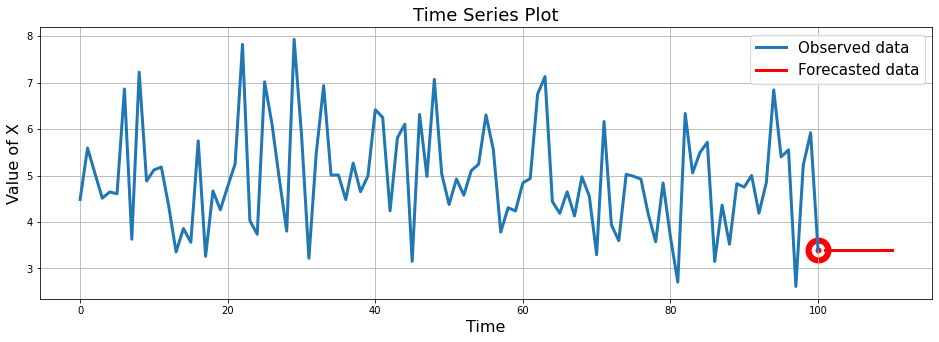

In [ ]:
# plot the observed and the forecasted data
plot_series(X, X_preds, plot_dot=True)

The above figure shows the time series plot of the observed data with the forecasted values. The blue curve shows the observed data. The last value, which is the $100^{th}$ value of the time series data, is highlighted with a red circle. Note that we're using zero-based indexing for the time series. The values after the $100^{th}$ timestamp are the forecasts made by the model. This is shown by a horizontal red line, emerging out from the red circle. 



### Mean Method

In the mean method, all the forecasts are equal to the mean of the observed data. In other words, if we have a time series up to time $T$, the predictions at $T + k \quad k = 1, 2,....$ are equal to the mean of the observed data. The mean method also does not have any parameter to learn as in the naive method.



#### Mathematical Expression

Given a time-series $X = \{x_t\} _{t = 0} ^T$, the mean method predicts future predictions as:

> $X_{T + k} = \frac {\sum _{n = 0} ^{T} x_n}{T + 1} \quad \quad k = 1, 2, ...$


### Implementation

Let's implement the mean method. We'll define a class named `MeanMethod` with two methods: `__init__` and `forecast`. 


In [ ]:
# implementation of Mean method

class MeanMethod:
    def __init__(self, X):
        # calculate the mean of the observed data and store it
        self.mean_val = np.mean(X) 

    def forecast(self, n=1):
        """ Forecast function

            Args:
                n (int): Number of forecasts to make
            
            Returns:
                np.array of length n with all values equal to mean_val

        """
        return np.zeros(n) + self.mean_val 

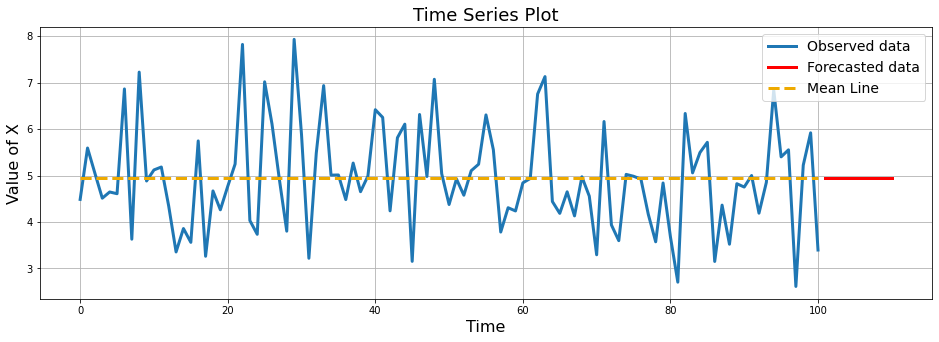

In [ ]:
mean_method = MeanMethod(X)

# generate 10 forecasts using the mean method
X_preds = mean_method.forecast(n=10)

# plot the observed and the forecasted data
plot_series(X, X_preds, plot_mean=True)

The blue curve shows the observed time-series. Similarly, the yellow dashed line shows the mean for the observed time-series. The forecasted values from 101 to 110 timestamps are shown by the red horizontal line, extending the mean line. 



The naive method and the mean method are simple. These methods don't involve any model fitting and learning of parameters. However, the forecasts are flat (meaning all the future forecasts are the same). Thus, these methods cannot model data with trends and seasonality. Nevertheless, we can use them as baseline models and improve forecasts with other sophisticated models, which we'll discuss in the future chapters.


## Key Takeaways

1. The naive method returns all future predictions as the last observed value.

2. The mean method calculates the observed data's mean and every future forecast is equal to this mean.


## References

- Hyndman, R.J., & Athanasopoulos, G. (2018) Forecasting: principles and practice, 2nd edition, OTexts: Melbourne, Australia. OTexts.com/fpp2. 
    * Check https://otexts.com/fpp2/simple-methods.html to understand more simple forecasting methods. 
